In [1]:
import pandas as pd

In [2]:
d=pd.read_csv(r"C:\Users\HP\Downloads\NIFTY BANK-9-02-2026-to-9-03-2026.csv")
d

,Date,Open,High,Low,Close,Shares Traded,Turnover (₹ Cr)
0,06-MAR-2026,58629.60,58807.15,57696.40,57783.25,256863138,12219.20
1,05-MAR-2026,59008.25,59274.35,58506.40,59055.85,273526525,11232.25
2,04-MAR-2026,58447.15,59058.40,58393.55,58755.25,363102095,12336.06
3,02-MAR-2026,59204.30,60177.50,59148.00,59839.65,387102246,11729.09
4,27-FEB-2026,61057.45,61086.45,60438.95,60529.00,369227038,13055.66
5,26-FEB-2026,61193.90,61284.75,60813.30,61187.70,602742091,16566.50
6,25-FEB-2026,61175.05,61317.55,60816.75,61043.35,321648989,10957.98
7,24-FEB-2026,61392.10,61435.65,60801.85,61047.30,587726979,13885.44
8,23-FEB-2026,61145.55,61517.80,61029.15,61264.25,841881403,13925.19
9,20-FEB-2026,60627.85,61360.50,60562.35,61172.00,219798497,8317.93


In [3]:
from statsmodels.tsa.arima.model import ARIMA

In [4]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             19 non-null     object 
 1   Open             19 non-null     float64
 2   High             19 non-null     float64
 3   Low              19 non-null     float64
 4   Close            19 non-null     float64
 5   Shares Traded    19 non-null     int64  
 6   Turnover (₹ Cr)  19 non-null     float64
dtypes: float64(5), int64(1), object(1)
memory usage: 1.2+ KB


In [5]:
d.columns =d.columns.str.strip()
d['Date'] = pd.to_datetime(d['Date'], format="%d-%b-%Y")
d['Date']

0    2026-03-06
1    2026-03-05
2    2026-03-04
3    2026-03-02
4    2026-02-27
5    2026-02-26
6    2026-02-25
7    2026-02-24
8    2026-02-23
9    2026-02-20
10   2026-02-19
11   2026-02-18
12   2026-02-17
13   2026-02-16
14   2026-02-13
15   2026-02-12
16   2026-02-11
17   2026-02-10
18   2026-02-09
Name: Date, dtype: datetime64[ns]

In [6]:
d=d.sort_values("Date")
d

,Date,Open,High,Low,Close,Shares Traded,Turnover (₹ Cr)
18,2026-02-09,60805.20,60876.20,60495.70,60669.35,263383179,11866.25
17,2026-02-10,60740.80,60797.55,60531.55,60626.40,215859015,10409.67
16,2026-02-11,60670.25,60779.95,60444.65,60745.35,235120784,10187.01
15,2026-02-12,60786.15,60864.40,60597.65,60739.75,266999047,12991.36
14,2026-02-13,60504.40,60621.90,60073.55,60186.65,236603159,11648.08
13,2026-02-16,59947.80,61011.30,59861.10,60949.10,168628013,6913.02
12,2026-02-17,60821.15,61241.60,60560.00,61174.00,264042737,10267.27
11,2026-02-18,61255.35,61596.85,61100.90,61550.80,218063267,6931.18
10,2026-02-19,61660.85,61678.80,60592.90,60739.55,190638669,7669.36
9,2026-02-20,60627.85,61360.50,60562.35,61172.00,219798497,8317.93


In [7]:
nd=d.set_index("Date")["Close"]
nd

Date
2026-02-09    60669.35
2026-02-10    60626.40
2026-02-11    60745.35
2026-02-12    60739.75
2026-02-13    60186.65
2026-02-16    60949.10
2026-02-17    61174.00
2026-02-18    61550.80
2026-02-19    60739.55
2026-02-20    61172.00
2026-02-23    61264.25
2026-02-24    61047.30
2026-02-25    61043.35
2026-02-26    61187.70
2026-02-27    60529.00
2026-03-02    59839.65
2026-03-04    58755.25
2026-03-05    59055.85
2026-03-06    57783.25
Name: Close, dtype: float64

In [8]:
model=ARIMA(nd,order=(1,1,1))
mf=model.fit()
print(mf.summary())

C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                   19
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -139.839
Date:                Tue, 10 Mar 2026   AIC                            285.677
Time:                        11:46:51   BIC                            288.349
Sample:                             0   HQIC                           286.046
                                 - 19                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2104     26.787     -0.008      0.994     -52.713      52.292
ma.L1          0.2044     26.827      0.008      0.994     -52.375      52.784
sigma2      3.886e+05    1.7e+05      2.290      0.0

In [9]:
f=mf.forecast(steps=5)
f

C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


19    57791.402549
20    57789.687455
21    57790.048268
22    57789.972362
23    57789.988331
Name: predicted_mean, dtype: float64

In [10]:
fd=pd.date_range(start=nd.index[-1],periods=5,freq="D")
fd

DatetimeIndex(['2026-03-06', '2026-03-07', '2026-03-08', '2026-03-09',
               '2026-03-10'],
              dtype='datetime64[ns]', freq='D')

In [11]:
import matplotlib.pyplot as plt

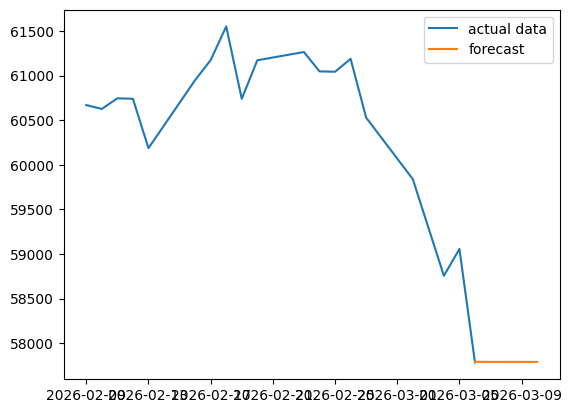

In [13]:
plt.plot(nd,label="actual data")
plt.plot(fd,f,label="forecast")


plt.legend()
plt.show()